In [ ]:
import torch
import torch.nn as nn
from torch.nn.functional import relu
from image_processing import read_img
from sklearn.model_selection import train_test_split
import os
import cv2
import numpy as np
from math import ceil

device="cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Used device: {device}")

#CONSTANTS
INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"
SAVED_MODELS:str="./saved_models"

#PATHS
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

Used device: cuda


In [2]:
class UNet(nn.Module):
    def __init__(self, n_class):
        super().__init__()

        # input: 572x572x3
        self.e11 = nn.Conv2d(3, 64, kernel_size=3, padding=1) # output: 570x570x64
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1) # output: 568x568x64
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 284x284x64

        # input: 284x284x64
        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # output: 282x282x128
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1) # output: 280x280x128
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 140x140x128

        # input: 140x140x128
        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # output: 138x138x256
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1) # output: 136x136x256
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 68x68x256

        # input: 68x68x256
        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1) # output: 66x66x512
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1) # output: 64x64x512
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 32x32x512

        # input: 32x32x512
        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1) # output: 30x30x1024
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1) # output: 28x28x1024


        # Decoder
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.d11 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
        self.d12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d21 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.d22 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d31 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.d32 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d41 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.d42 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # Output layer
        self.outconv = nn.Conv2d(64, n_class, kernel_size=1)

    def forward(self, x):
        # Encoder
        xe11 = relu(self.e11(x))
        xe12 = relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = relu(self.e21(xp1))
        xe22 = relu(self.e22(xe21))
        xp2 = self.pool2(xe22)

        xe31 = relu(self.e31(xp2))
        xe32 = relu(self.e32(xe31))
        xp3 = self.pool3(xe32)

        xe41 = relu(self.e41(xp3))
        xe42 = relu(self.e42(xe41))
        xp4 = self.pool4(xe42)

        xe51 = relu(self.e51(xp4))
        xe52 = relu(self.e52(xe51))
        
        # Decoder
        xu1 = self.upconv1(xe52)
        xu11 = torch.cat([xu1, xe42], dim=1)
        xd11 = relu(self.d11(xu11))
        xd12 = relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xu22 = torch.cat([xu2, xe32], dim=1)
        xd21 = relu(self.d21(xu22))
        xd22 = relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xu33 = torch.cat([xu3, xe22], dim=1)
        xd31 = relu(self.d31(xu33))
        xd32 = relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xu44 = torch.cat([xu4, xe12], dim=1)
        xd41 = relu(self.d41(xu44))
        xd42 = relu(self.d42(xd41))

        # Output layer
        out = self.outconv(xd42)

        return out

In [3]:
def load_training_patches(image_paths, mask_paths,size:int=512, patch_size:int=256,percent_of_images:float=0.5):
    x_patches = []
    y_patches = []
    max_id=ceil(len(image_paths)*percent_of_images)
    for idx,(img_p, mask_p) in enumerate(zip(image_paths, mask_paths)):
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size,size))

        mask = cv2.imread(str(mask_p), cv2.IMREAD_GRAYSCALE)
        mask=cv2.resize(mask,(size,size))

        h, w = img.shape[:2]

        for y in range(0, h - patch_size + 1, patch_size):
            for x in range(0, w - patch_size + 1, patch_size):
                patch_img = img[y : y + patch_size, x : x + patch_size]
                patch_mask = mask[y : y + patch_size, x : x + patch_size]

                if np.max(patch_img) > 15:
                    patch_img = patch_img.astype(np.float32) / 255.0
                    patch_img = np.transpose(patch_img, (2, 0, 1))
                    patch_mask = patch_mask.astype(np.float32) / 255.0
                    patch_mask = np.expand_dims(patch_mask, axis=0)

                    x_patches.append(patch_img)
                    y_patches.append(patch_mask)
        if idx>=max_id:
            break

    return torch.tensor(np.array(x_patches),device=device), torch.tensor(np.array(y_patches),device=device)

In [4]:

print(torch.cuda.get_device_name(0))

total_vram = torch.cuda.get_device_properties(0).total_memory

print(f"VRAM: {total_vram / 1024**3:.2f} GB")

NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.00 GB


In [5]:
model = UNet(1).to(device)
print(f"The model will be trained on {next(model.parameters()).device}")

epochs=5_000
batch_size=8
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X,y=load_training_patches(input_images,manual_images,percent_of_images=0.80)
X_train_patches, X_test, Y_train_patches, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
num_train_samples = X_train_patches.size()[0]
old_ang_loss=float("inf")

The model will be trained on cuda:0


In [ ]:

print("Started the training ")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    permutation = torch.randperm(num_train_samples)

    for i in range(0, num_train_samples, batch_size):
        indices = permutation[i : i + batch_size]

        batch_x = X_train_patches[indices].float().to(device)
        batch_y = Y_train_patches[indices].float().to(device)

        pred_y = model(batch_x)

        loss = criterion(pred_y, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (num_train_samples / batch_size)
    if avg_loss<old_ang_loss:
        torch.save(model.state_dict(), SAVED_MODELS+"/"+'model_weights_best_found.pth')

    old_ang_loss=avg_loss
    if avg_loss<=0.0100:#zeby zapobiec przeuczeniu
        break
    if epoch%100==0:
        print(f"Epoch: {epoch + 1} z {epochs} Mean error: {avg_loss:.4f}")

Started the training 
Epoch: 1 z 5000 Mean error: 0.6362
Epoch: 101 z 5000 Mean error: 0.1218
Epoch: 201 z 5000 Mean error: 0.0724
Epoch: 301 z 5000 Mean error: 0.0349
Epoch: 401 z 5000 Mean error: 0.0246
Epoch: 501 z 5000 Mean error: 0.0286
Epoch: 601 z 5000 Mean error: 0.0186
Epoch: 701 z 5000 Mean error: 0.0176
Epoch: 801 z 5000 Mean error: 0.0144
Epoch: 901 z 5000 Mean error: 0.0143
Epoch: 1001 z 5000 Mean error: 0.0135
Epoch: 1101 z 5000 Mean error: 0.0129
Epoch: 1201 z 5000 Mean error: 0.0127
Epoch: 1301 z 5000 Mean error: 0.0118


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), SAVED_MODELS+"/"+'model_weights_newest.pth')


In [ ]:
model = UNet(1).to(device)
model.load_state_dict(torch.load(SAVED_MODELS+"/"+"model_weights_best_found.pth", weights_only=True))

<All keys matched successfully>

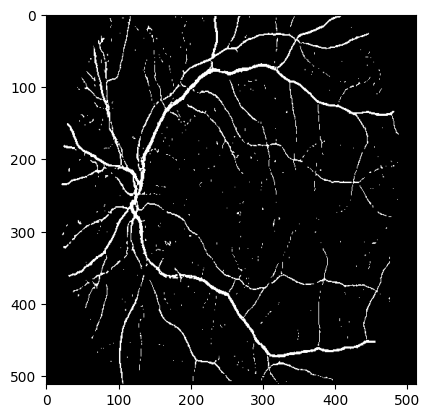

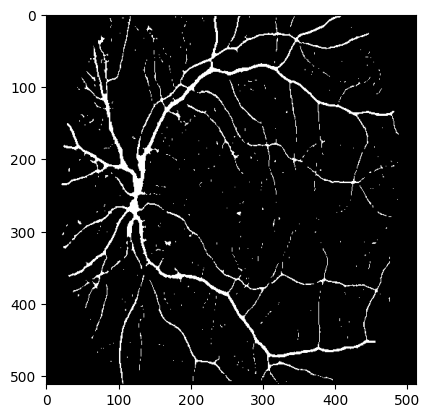

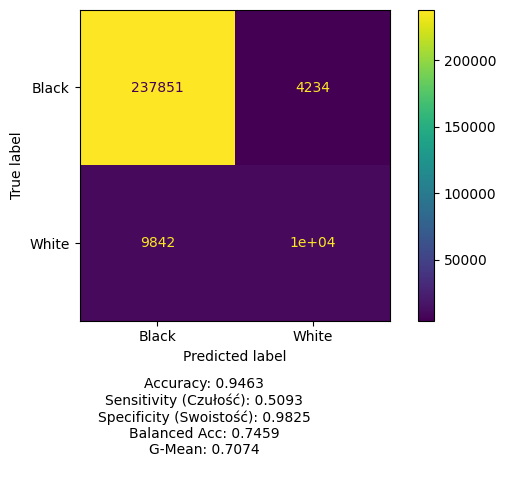

In [13]:
import gc
import cv2
import torch
import numpy as np
from image_processing import show_img
from simple_statistics import create_confusions_matrix
from image_processing import postproces_pipeline

# --- ścieżki ---
image_path = "./images/14_dr.JPG"
mask_path  = "./manual1/14_dr.tif"   # podmień na swoją prawdziwą maskę

# --- czyszczenie VRAM ---
gc.collect()
torch.cuda.empty_cache()

# --- model ---
model.eval()

# --- wczytanie obrazu ---
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# --- dopasowanie rozmiaru do treningu ---
size = 512
img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

# --- normalizacja i zmiana układu wymiarów ---
img = img.astype(np.float32) / 255.0
img = np.transpose(img, (2, 0, 1))          # HWC -> CHW
img = np.expand_dims(img, axis=0)           # CHW -> NCHW

mask = (mask > 0).astype(np.uint8)

# --- tensor na GPU ---
X = torch.tensor(img, dtype=torch.float32, device=device)

# --- predykcja ---
with torch.no_grad():
    result = model(X)
    result = torch.sigmoid(result)
    result = (result > 0.5).float()


# --- CPU + numpy ---
pred = result.squeeze(0).squeeze(0).cpu().numpy().astype(np.uint8)
show_img(pred)
pred=postproces_pipeline(pred,5)
show_img(pred)
true = mask.astype(np.uint8)


# --- upewnienie się, że rozmiary są identyczne ---
h = min(true.shape[0], pred.shape[0])
w = min(true.shape[1], pred.shape[1])

true = true[:h, :w]
pred = pred[:h, :w]

# --- macierz pomyłek ---
create_confusions_matrix(
    true.flatten(),
    pred.flatten()
)